<div style=" background-color: RGB(0,114,200);" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET 4 DATA ANALYST</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Réalisez une étude de santé publique avec R ou Python
</h2>
</div>

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.2 - Chargement des fichiers CSV</h3>
</div>

In [2]:
population = pd.read_csv("population.csv")

In [3]:
dispo_alimentaire = pd.read_csv("dispo_alimentaire.csv")

In [4]:
aide_alimentaire = pd.read_csv("aide_alimentaire.csv")

In [5]:
sous_nutrition = pd.read_csv("sous_nutrition.csv")

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.3 - Autres paramètres généraux</h3>
</div>

In [6]:
from itertools import chain

In [7]:
# world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
# AttributeError: The geopandas.dataset has been deprecated and was removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.

# Archive "110m_cultural.zip" téléchargée et extraite dans un sous-dossier du même nom à côté du notebook
world = gpd.read_file("110m_cultural/ne_110m_admin_0_countries.shp")

# Ne pas afficher l'Antarctique
world = world[ (world["NAME"] != "Antarctica") ]

In [8]:
def draw_world_map(d):
    """
    Dessine une carte du monde avec des groupes de pays coloriés (une couleur par groupe)
    
    Parameters:
        d (dict): Groupes de pays (clé = couleur, valeur = noms anglophones de pays)
    """
    ax = world.plot(edgecolor="gray", color="whitesmoke", figsize=(15,15))
    for color, names in d.items():
        df = world[ world["NAME_LONG"].isin(names) ]
        assert df.shape[0] == len(names), f"La liste des pays pour la couleur {color} contient (au moins) un nom invalide."
        df.plot(edgecolor="gray", color=color, ax=ax)
    plt.axis("off")
    plt.show()

In [9]:
sns.set_theme(style="darkgrid", palette="bright")

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Analyse exploratoire du fichier population</h3>
</div>

In [10]:
print(f"Le tableau comporte {population.shape[0]} ligne(s) et {population.shape[1]} colonne(s).")

Le tableau comporte 1416 ligne(s) et 3 colonne(s).


In [11]:
population.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 1416 entries, 0 to 1415
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Zone    1416 non-null   str    
 1   Année   1416 non-null   int64  
 2   Valeur  1416 non-null   float64
dtypes: float64(1), int64(1), str(1)
memory usage: 33.3 KB


In [12]:
population.head(5)

,Zone,Année,Valeur
0,Afghanistan,2013,32269.589
1,Afghanistan,2014,33370.794
2,Afghanistan,2015,34413.603
3,Afghanistan,2016,35383.032
4,Afghanistan,2017,36296.113


In [13]:
# Conversion : milliers d'habitants -> habitants
population["Population"] = (1000 * population["Valeur"]).astype(int)
del population["Valeur"]

In [14]:
population.head(5)

,Zone,Année,Population
0,Afghanistan,2013,32269589
1,Afghanistan,2014,33370794
2,Afghanistan,2015,34413603
3,Afghanistan,2016,35383032
4,Afghanistan,2017,36296113


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Analyse exploratoire du fichier disponibilité alimentaire</h3>
</div>

In [15]:
print(f"Le tableau comporte {dispo_alimentaire.shape[0]} ligne(s) et {sous_nutrition.shape[1]} colonne(s).")

Le tableau comporte 15605 ligne(s) et 3 colonne(s).


In [16]:
dispo_alimentaire.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 15605 entries, 0 to 15604
Data columns (total 18 columns):
 #   Column                                                         Non-Null Count  Dtype  
---  ------                                                         --------------  -----  
 0   Zone                                                           15605 non-null  str    
 1   Produit                                                        15605 non-null  str    
 2   Origine                                                        15605 non-null  str    
 3   Aliments pour animaux                                          2720 non-null   float64
 4   Autres Utilisations                                            5496 non-null   float64
 5   Disponibilité alimentaire (Kcal/personne/jour)                 14241 non-null  float64
 6   Disponibilité alimentaire en quantité (kg/personne/an)         14015 non-null  float64
 7   Disponibilité de matière grasse en quantité (g/personne/jour)  11794 

In [17]:
dispo_alimentaire.head(5)

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN


In [18]:
# Remplacer tous les NaN par 0
dispo_alimentaire.fillna(0, inplace=True)

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53.0,0.0,0.0,53.0,0.0,53.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82.0,0.0,82.0,82.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15600,Îles Salomon,Viande de Suides,animale,0.0,0.0,45.0,4.70,4.28,1.41,3.0,0.0,0.0,3.0,0.0,2.0,0.0,0.0,0.0
15601,Îles Salomon,Viande de Volailles,animale,0.0,0.0,11.0,3.34,0.69,1.14,2.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0
15602,Îles Salomon,"Viande, Autre",animale,0.0,0.0,0.0,0.06,0.00,0.04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15603,Îles Salomon,Vin,vegetale,0.0,0.0,0.0,0.07,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
# Conversion : milliers de tonnes -> kg (4 + 6 + 1 = 11 colonnes)
for colonne in [
    "Production", "Importations - Quantité", "Exportations - Quantité", "Variation de stock",
    "Semences", "Pertes", "Nourriture", "Aliments pour animaux", "Traitement", "Autres Utilisations",
    "Disponibilité intérieure",
]:
    dispo_alimentaire[colonne] = (dispo_alimentaire[colonne] * 1e6).astype(int)

In [20]:
# Harmonisation des unités des 4 colonnes de disponibilité en masse/personne/temps : tout en g/personne/jour
avant = "Disponibilité alimentaire en quantité (kg/personne/an)"
apres = "Disponibilité alimentaire en quantité (g/personne/jour)"
dispo_alimentaire[avant] *= 1000. / 365.
dispo_alimentaire.rename(columns={avant:apres}, inplace=True)

In [21]:
dispo_alimentaire.head(5)

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (g/personne/jour),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0,0,5.0,4.712329,0.20,0.77,53000000,0,0,53000000,0,53000000,0,0,0
1,Afghanistan,"Agrumes, Autres",vegetale,0,0,1.0,3.534247,0.01,0.02,41000000,2000000,40000000,39000000,2000000,3000000,0,0,0
2,Afghanistan,Aliments pour enfants,vegetale,0,0,1.0,0.164384,0.01,0.03,2000000,0,2000000,2000000,0,0,0,0,0
3,Afghanistan,Ananas,vegetale,0,0,0.0,0.000000,0.00,0.00,0,0,0,0,0,0,0,0,0
4,Afghanistan,Bananes,vegetale,0,0,4.0,7.397260,0.02,0.05,82000000,0,82000000,82000000,0,0,0,0,0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier aide alimentaire</h3>
</div>

In [22]:
print(f"Le tableau comporte {aide_alimentaire.shape[0]} ligne(s) et {sous_nutrition.shape[1]} colonne(s).")

Le tableau comporte 1475 ligne(s) et 3 colonne(s).


In [23]:
aide_alimentaire.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 1475 entries, 0 to 1474
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Pays bénéficiaire  1475 non-null   str  
 1   Année              1475 non-null   int64
 2   Produit            1475 non-null   str  
 3   Valeur             1475 non-null   int64
dtypes: int64(2), str(2)
memory usage: 46.2 KB


In [24]:
aide_alimentaire.head(5)

,Pays bénéficiaire,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504


In [25]:
# Renommer la colonne Pays bénéficiaire en Zone
aide_alimentaire.rename(columns={"Pays bénéficiaire":"Zone"}, inplace=True)

In [26]:
# Conversion : tonne -> kg
aide_alimentaire["Aide alimentaire"] = aide_alimentaire["Valeur"] * 1000
del aide_alimentaire["Valeur"]

In [27]:
aide_alimentaire.head(5)

,Zone,Année,Produit,Aide alimentaire
0,Afghanistan,2013,Autres non-céréales,682000
1,Afghanistan,2014,Autres non-céréales,335000
2,Afghanistan,2013,Blé et Farin,39224000
3,Afghanistan,2014,Blé et Farin,15160000
4,Afghanistan,2013,Céréales,40504000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.4 - Analyse exploratoire du fichier sous nutrition</h3>
</div>

In [28]:
print(f"Le tableau comporte {sous_nutrition.shape[0]} ligne(s) et {sous_nutrition.shape[1]} colonne(s).")

Le tableau comporte 1218 ligne(s) et 3 colonne(s).


In [29]:
sous_nutrition.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Zone    1218 non-null   str  
 1   Année   1218 non-null   str  
 2   Valeur  624 non-null    str  
dtypes: str(3)
memory usage: 28.7 KB


In [30]:
sous_nutrition.head(10)

,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5
5,Afghanistan,2017-2019,11.1
6,Afrique du Sud,2012-2014,2.2
7,Afrique du Sud,2013-2015,2.5
8,Afrique du Sud,2014-2016,2.8
9,Afrique du Sud,2015-2017,3


In [31]:
# Convertir f"{N-1}-{N+1}" en N
def handle_2_year_range(s: str) -> int:
    a, b = map(int, s.split('-'))
    assert a >= 2000
    assert a + 2 == b
    return a + 1
sous_nutrition["Année"] = sous_nutrition["Année"].map(handle_2_year_range)

In [32]:
# Convertir avec l'argument errors='coerce' (renvoie NaN au lieu de 'raise')
sous_nutrition["Valeur"] = pd.to_numeric(sous_nutrition["Valeur"], errors="coerce")
# Remplacer tous les NaN par 0
sous_nutrition.fillna(0, inplace=True)

,Zone,Année,Valeur
0,Afghanistan,2013,8.6
1,Afghanistan,2014,8.8
2,Afghanistan,2015,8.9
3,Afghanistan,2016,9.7
4,Afghanistan,2017,10.5
...,...,...,...
1213,Zimbabwe,2014,0.0
1214,Zimbabwe,2015,0.0
1215,Zimbabwe,2016,0.0
1216,Zimbabwe,2017,0.0


In [33]:
# Conversion : milliers de tonnes -> kg
sous_nutrition["Sous nutrition"] = (sous_nutrition["Valeur"] * 1e6).astype(int)
del sous_nutrition["Valeur"]

In [34]:
sous_nutrition.head(10)

,Zone,Année,Sous nutrition
0,Afghanistan,2013,8600000
1,Afghanistan,2014,8800000
2,Afghanistan,2015,8900000
3,Afghanistan,2016,9700000
4,Afghanistan,2017,10500000
5,Afghanistan,2018,11100000
6,Afrique du Sud,2013,2200000
7,Afrique du Sud,2014,2500000
8,Afrique du Sud,2015,2800000
9,Afrique du Sud,2016,3000000


Forme générale : 6 intervalles &times; 203 pays = 1218 lignes

In [35]:
sous_nutrition.groupby("Année").count()

,Zone,Sous nutrition
Année,,
2013,203,203
2014,203,203
2015,203,203
2016,203,203
2017,203,203
2018,203,203


In [36]:
sous_nutrition.groupby("Zone").count()

,Année,Sous nutrition
Zone,,
Afghanistan,6,6
Afrique du Sud,6,6
Albanie,6,6
Algérie,6,6
Allemagne,6,6
...,...,...
États-Unis d'Amérique,6,6
Éthiopie,6,6
Îles Cook,6,6


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Etude sur la faim dans le monde entre 2013 et 2017</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">
3.1 - Proportion de personnes en sous nutrition en 2017
</h3>
</div>

In [37]:
population_2017 = population[ (population["Année"] == 2017) ]
del population_2017["Année"]
population_2017

,Zone,Population
4,Afghanistan,36296113
10,Afrique du Sud,57009756
16,Albanie,2884169
22,Algérie,41389189
28,Allemagne,82658409
...,...,...
1390,Venezuela (République bolivarienne du),29402484
1396,Viet Nam,94600648
1402,Yémen,27834819
1408,Zambie,16853599


In [38]:
sous_nutrition_2017 = sous_nutrition[ (sous_nutrition["Année"] == 2017) ]
del sous_nutrition_2017["Année"]
sous_nutrition_2017

,Zone,Sous nutrition
4,Afghanistan,10500000
10,Afrique du Sud,3100000
16,Albanie,100000
22,Algérie,1300000
28,Allemagne,0
...,...,...
1192,Venezuela (République bolivarienne du),8000000
1198,Viet Nam,6500000
1204,Yémen,0
1210,Zambie,0


In [39]:
df1 = pd.merge(population_2017, sous_nutrition_2017, how="inner")
print(df1.sum(numeric_only=True))

Population        7543798769
Sous nutrition     535700000
dtype: int64


In [40]:
df1l = pd.merge(population_2017, sous_nutrition_2017, how="left" )
print(f"{df1l["Sous nutrition"].isna().sum()} zone(s) sans données de sous nutrition")
# print(df1l.sum(numeric_only=True))
print(df1l.sum(numeric_only=True).astype(int))

33 zone(s) sans données de sous nutrition
Population        7548134097
Sous nutrition     535700000
dtype: int64


In [41]:
df1r = pd.merge(population_2017, sous_nutrition_2017, how="right")
print(f"{df1r["Population"].isna().sum()} zone(s) sans données de population")
print(df1r.sum(numeric_only=True))

0 zone(s) sans données de population
Population        7543798769
Sous nutrition     535700000
dtype: int64


In [42]:
num = sous_nutrition_2017["Sous nutrition"].sum()
den = population_2017["Population"].sum()
print(f"En 2017, {num:_} personnes sur {den:_} étaient en sous nutrition, soit {100.*num/den:.2f}% de la population mondiale.")

En 2017, 535_700_000 personnes sur 7_548_134_097 étaient en sous nutrition, soit 7.10% de la population mondiale.


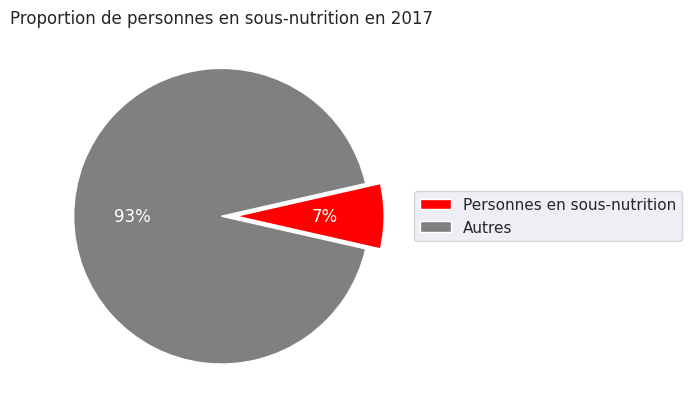

In [43]:
plt.pie([num,den-num], colors=["red","gray"], autopct="%.0f%%", textprops={"color":"white"}, startangle=-180*num/den, explode=[0.1,0])
plt.legend(["Personnes en sous-nutrition","Autres"], loc="center left", bbox_to_anchor=(1,0.5))
plt.title("Proportion de personnes en sous-nutrition en 2017")
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">
3.2 - Nombre théorique de personnes qui pourraient être nourries en 2017
</h3>
</div>

- [Wikipédia](https://fr.wikipedia.org/wiki/Ration_alimentaire) : 2500 kcal (moyenne)
- [vidal.fr](https://www.vidal.fr/sante/nutrition/equilibre-alimentaire-adulte/recommandations-nutritionnelles-adulte.html) : recommandations pour les adultes, selon le sexe
    - Entre 2400 et 2600 kcal pour un homme
    - Entre 1800 et 2200 kcal pour une femme

In [44]:
kcal_1_personne_1_jour_min = 2000
kcal_1_personne_1_jour_max = 2500

In [45]:
avant = "Disponibilité alimentaire (Kcal/personne/jour)"
apres = "kcal/personne/jour"
df2 = pd.merge(population_2017, dispo_alimentaire[["Zone",avant]], how="left")
df2 = df2.groupby(["Zone","Population"]).sum().reset_index()
df2.rename(columns={avant:apres}, inplace=True)
df2["kcal/jour"] = df2["Population"] * df2[apres]
df2

,Zone,Population,kcal/personne/jour,kcal/jour
0,Afghanistan,36296113,2087.0,7.574999e+10
1,Afrique du Sud,57009756,3020.0,1.721695e+11
2,Albanie,2884169,3188.0,9.194731e+09
3,Algérie,41389189,3293.0,1.362946e+11
4,Allemagne,82658409,3503.0,2.895524e+11
...,...,...,...,...
231,Îles Salomon,636039,2383.0,1.515681e+09
232,Îles Turques-et-Caïques,37115,0.0,0.000000e+00
233,Îles Vierges américaines,104751,0.0,0.000000e+00
234,Îles Vierges britanniques,29577,0.0,0.000000e+00


In [46]:
nb_personnes_nourries_min = round(df2["kcal/jour"].sum() / kcal_1_personne_1_jour_max)
nb_personnes_nourries_max = round(df2["kcal/jour"].sum() / kcal_1_personne_1_jour_min)
print(f"Nombre min de personnes pouvant être nourries : {nb_personnes_nourries_min:_}")
print(f"Nombre max de personnes pouvant être nourries : {nb_personnes_nourries_max:_}")

Nombre min de personnes pouvant être nourries : 8_367_593_844
Nombre max de personnes pouvant être nourries : 10_459_492_305


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">
3.3 - Nombre théorique de personnes qui pourraient être nourries avec des produits végétaux en 2017
</h3>
</div>

In [47]:
avant = "Disponibilité alimentaire (Kcal/personne/jour)"
apres = "kcal/personne/jour"
dispo_vegetaux = dispo_alimentaire[ (dispo_alimentaire["Origine"] == "vegetale") ]
df3 = pd.merge(population_2017, dispo_vegetaux[["Zone",avant]], how="left")
df3 = df3.groupby(["Zone","Population"]).sum().reset_index()
df3.rename(columns={avant:apres}, inplace=True)
df3["kcal/jour"] = df3["Population"] * df3[apres]
df3

,Zone,Population,kcal/personne/jour,kcal/jour
0,Afghanistan,36296113,1871.0,6.791003e+10
1,Afrique du Sud,57009756,2533.0,1.444057e+11
2,Albanie,2884169,2203.0,6.353824e+09
3,Algérie,41389189,2915.0,1.206495e+11
4,Allemagne,82658409,2461.0,2.034223e+11
...,...,...,...,...
231,Îles Salomon,636039,2187.0,1.391017e+09
232,Îles Turques-et-Caïques,37115,0.0,0.000000e+00
233,Îles Vierges américaines,104751,0.0,0.000000e+00
234,Îles Vierges britanniques,29577,0.0,0.000000e+00


In [48]:
nb_personnes_nourries_vegetaux_min = round(df3["kcal/jour"].sum() / kcal_1_personne_1_jour_max)
nb_personnes_nourries_vegetaux_max = round(df3["kcal/jour"].sum() / kcal_1_personne_1_jour_min)
print(f"Nombre min de personnes pouvant être nourries (végétaux) : {nb_personnes_nourries_vegetaux_min:_}")
print(f"Nombre max de personnes pouvant être nourries (végétaux) : {nb_personnes_nourries_vegetaux_max:_}")

Nombre min de personnes pouvant être nourries (végétaux) : 6_904_305_679
Nombre max de personnes pouvant être nourries (végétaux) : 8_630_382_099


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4 - Utilisation de la disponibilité intérieure</h3>
</div>

In [49]:
colonnes = ["Semences","Pertes","Nourriture","Aliments pour animaux","Traitement","Autres Utilisations"]
df4 = dispo_alimentaire[colonnes].sum().sort_values(ascending=False).reset_index()
df4.rename(columns={"index":"Utilisation",0:"Quantité (kg)"}, inplace=True)
df4

,Utilisation,Quantité (kg)
0,Nourriture,4876258000000
1,Traitement,2204687000000
2,Aliments pour animaux,1304245000000
3,Autres Utilisations,865023000000
4,Pertes,453698000000
5,Semences,154681000000


In [50]:
df4["Quantité (milliards de tonnes)"] = df4["Quantité (kg)"] / 1e12
df4

,Utilisation,Quantité (kg),Quantité (milliards de tonnes)
0,Nourriture,4876258000000,4.876258
1,Traitement,2204687000000,2.204687
2,Aliments pour animaux,1304245000000,1.304245
3,Autres Utilisations,865023000000,0.865023
4,Pertes,453698000000,0.453698
5,Semences,154681000000,0.154681


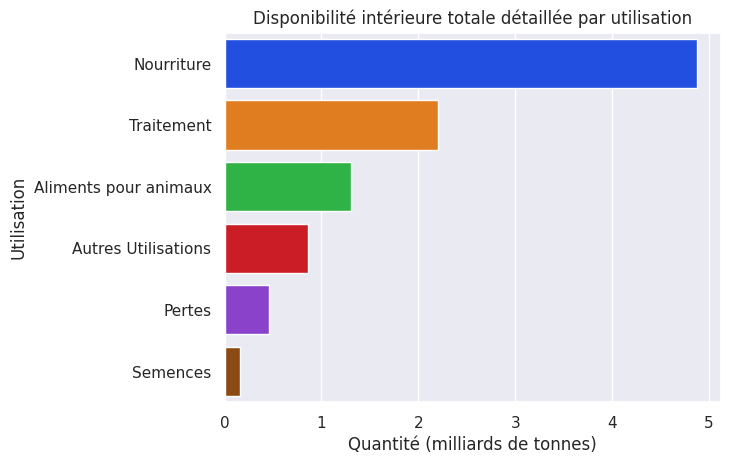

In [51]:
sns.barplot(df4, x="Quantité (milliards de tonnes)", y="Utilisation", hue="Utilisation")
plt.title("Disponibilité intérieure totale détaillée par utilisation")
plt.show()

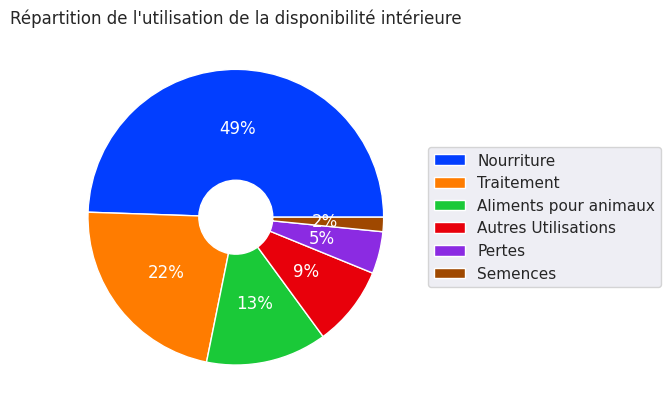

In [52]:
plt.pie(df4["Quantité (kg)"], autopct="%.0f%%", wedgeprops={"width":0.75}, textprops={"color":"white"})
plt.legend(df4["Utilisation"], loc="center left", bbox_to_anchor=(1,0.5))
plt.title("Répartition de l'utilisation de la disponibilité intérieure")
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.5 - Utilisation des céréales</h3>
</div>

In [53]:
cereales = [
    "Blé",
    "Riz (Eq Blanchi)",
    "Orge",
    "Maïs",
    "Seigle",
    "Avoine",
    "Millet",
    "Sorgho",
    "Céréales, Autres",
]
cereales.sort()
cereales

['Avoine',
 'Blé',
 'Céréales, Autres',
 'Maïs',
 'Millet',
 'Orge',
 'Riz (Eq Blanchi)',
 'Seigle',
 'Sorgho']

In [54]:
categories = {
    "Alimentation humaine": { "Nourriture" },
    "Alimentation animale": { "Aliments pour animaux" }, 
    "Non alimentaire": { "Semences", "Pertes", "Traitement", "Autres Utilisations" },
}
categories

{'Alimentation humaine': {'Nourriture'},
 'Alimentation animale': {'Aliments pour animaux'},
 'Non alimentaire': {'Autres Utilisations',
  'Pertes',
  'Semences',
  'Traitement'}}

In [55]:
df5 = dispo_alimentaire[ dispo_alimentaire["Produit"].isin(cereales) ]
df5 = df5[["Produit",*chain(*categories.values())]]
df5 = df5.groupby("Produit").sum()
for key, values in categories.items():
    df5[key] = sum(df5[value] for value in values)
for value in chain(*categories.values()):
    del df5[value]
df5.columns.name = "Catégorie"
df5

Catégorie,Alimentation humaine,Alimentation animale,Non alimentaire
Produit,,,
Avoine,3903000000,16251000000,3241000000
Blé,457824000000,129668000000,92114000000
"Céréales, Autres",5324000000,19035000000,3536000000
Maïs,125184000000,546116000000,284572000000
Millet,23040000000,3306000000,3557000000
Orge,6794000000,92658000000,40996000000
Riz (Eq Blanchi),377286000000,33594000000,64776000000
Seigle,5502000000,8099000000,2964000000
Sorgho,24153000000,24808000000,9278000000


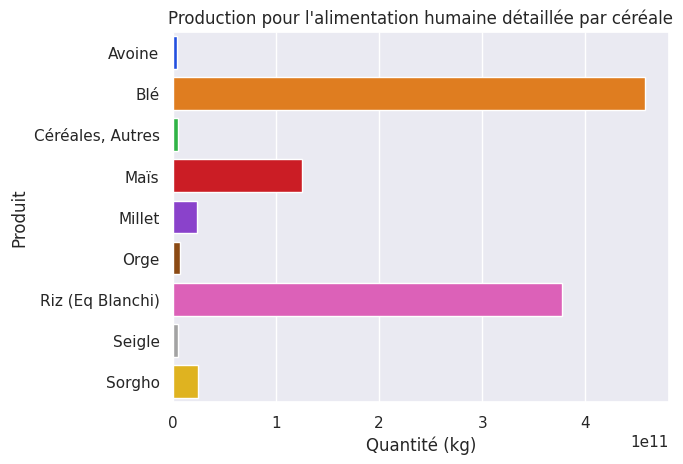

In [56]:
sns.barplot(df5, x="Alimentation humaine", y="Produit", hue="Produit")
plt.xlabel("Quantité (kg)")
plt.title("Production pour l'alimentation humaine détaillée par céréale")
plt.show()

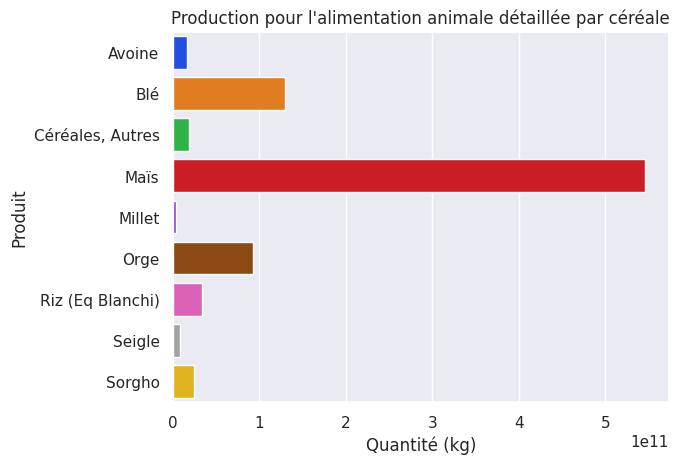

In [57]:
sns.barplot(df5, x="Alimentation animale", y="Produit", hue="Produit")
plt.xlabel("Quantité (kg)")
plt.title("Production pour l'alimentation animale détaillée par céréale")
plt.show()

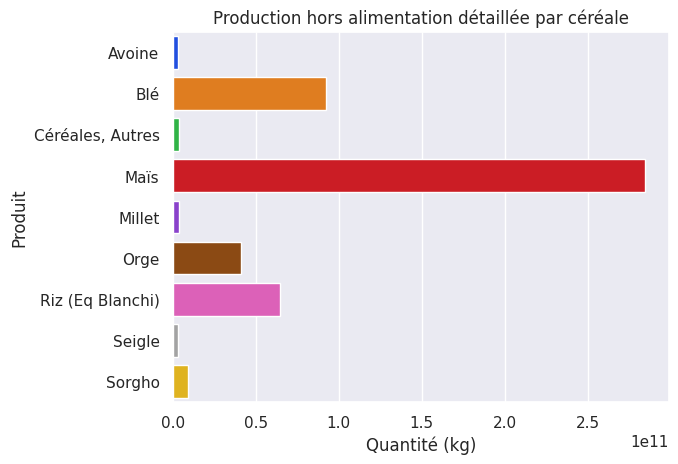

In [58]:
sns.barplot(df5, x="Non alimentaire", y="Produit", hue="Produit")
plt.xlabel("Quantité (kg)")
plt.title("Production hors alimentation détaillée par céréale")
plt.show()

In [59]:
df5_total_col = df5.sum().reset_index(name="Quantité (kg)")
df5_total_col

,Catégorie,Quantité (kg)
0,Alimentation humaine,1029010000000
1,Alimentation animale,873535000000
2,Non alimentaire,505034000000


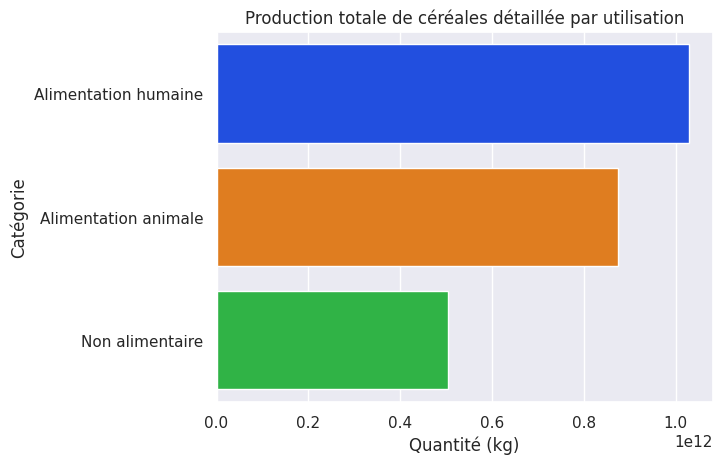

In [60]:
sns.barplot(df5_total_col, x="Quantité (kg)", y="Catégorie", hue="Catégorie")
plt.title("Production totale de céréales détaillée par utilisation")
plt.show()

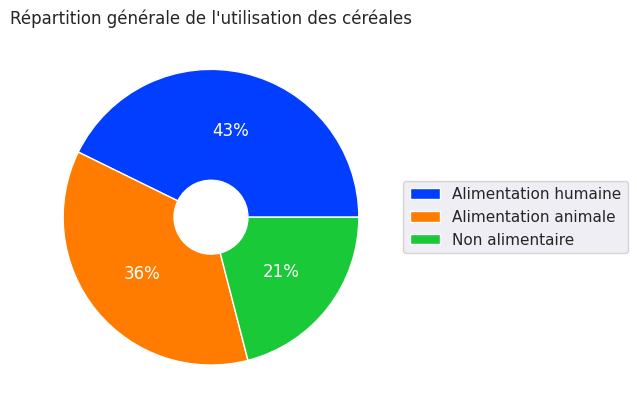

In [61]:
plt.pie(df5_total_col["Quantité (kg)"], autopct="%.0f%%", wedgeprops={"width":0.75}, textprops={"color":"white"})
plt.legend(categories, loc="center left", bbox_to_anchor=(1,0.5))
plt.title("Répartition générale de l'utilisation des céréales")
plt.show()

In [62]:
df5_total_row = df5.sum(axis=1)
df5_total_row

Produit
Avoine               23395000000
Blé                 679606000000
Céréales, Autres     27895000000
Maïs                955872000000
Millet               29903000000
Orge                140448000000
Riz (Eq Blanchi)    475656000000
Seigle               16565000000
Sorgho               58239000000
dtype: int64

In [63]:
print(f"Production totale de céréales = {df5_total_row.sum():_} kg")

Production totale de céréales = 2_407_579_000_000 kg


In [64]:
df5_pct_row = df5 * 100
for key in categories:
    df5_pct_row[key] /= df5_total_row
df5_pct_row

Catégorie,Alimentation humaine,Alimentation animale,Non alimentaire
Produit,,,
Avoine,16.683052,69.463561,13.853387
Blé,67.366092,19.079879,13.554030
"Céréales, Autres",19.085858,68.238035,12.676107
Maïs,13.096314,57.132754,29.770932
Millet,77.049126,11.055747,11.895128
Orge,4.837378,65.973172,29.189451
Riz (Eq Blanchi),79.319088,7.062667,13.618245
Seigle,33.214609,48.892243,17.893148
Sorgho,41.472209,42.596885,15.930905


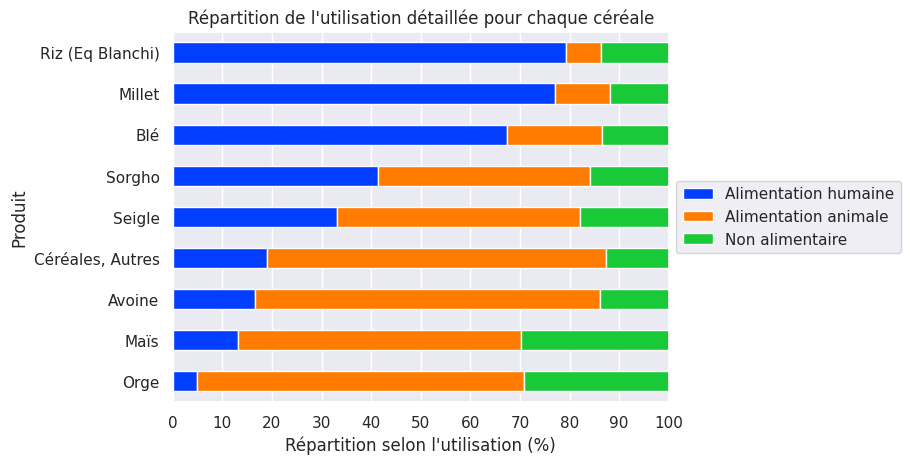

In [65]:
df5_pct_row.sort_values(by="Alimentation humaine").plot.barh(stacked=True)
plt.legend(categories, loc="center left", bbox_to_anchor=(1,0.5))
plt.xlabel("Répartition selon l'utilisation (%)")
plt.xticks(range(0,101,10))
plt.xlim(0, 100)
plt.title("Répartition de l'utilisation détaillée pour chaque céréale")
plt.show()

In [66]:
df5_melt = df5.reset_index().melt(id_vars=["Produit"], value_vars=categories, value_name="Quantité (kg)")
df5_melt["Quantité (millions de tonnes)"] = df5_melt["Quantité (kg)"] / 1e9
df5_melt

,Produit,Catégorie,Quantité (kg),Quantité (millions de tonnes)
0,Avoine,Alimentation humaine,3903000000,3.903
1,Blé,Alimentation humaine,457824000000,457.824
2,"Céréales, Autres",Alimentation humaine,5324000000,5.324
3,Maïs,Alimentation humaine,125184000000,125.184
4,Millet,Alimentation humaine,23040000000,23.040
5,Orge,Alimentation humaine,6794000000,6.794
6,Riz (Eq Blanchi),Alimentation humaine,377286000000,377.286
7,Seigle,Alimentation humaine,5502000000,5.502
8,Sorgho,Alimentation humaine,24153000000,24.153
9,Avoine,Alimentation animale,16251000000,16.251


In [67]:
order = df5_total_row.sort_values(ascending=False).index
order

Index(['Maïs', 'Blé', 'Riz (Eq Blanchi)', 'Orge', 'Sorgho', 'Millet',
       'Céréales, Autres', 'Avoine', 'Seigle'],
      dtype='str', name='Produit')

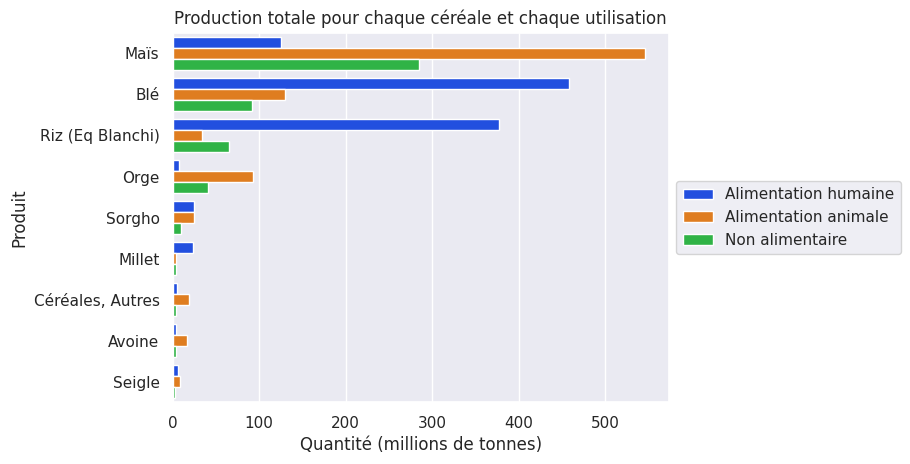

In [68]:
sns.barplot(df5_melt, x="Quantité (millions de tonnes)", y="Produit", hue="Catégorie", order=order)
plt.legend(loc="center left", bbox_to_anchor=(1,0.5))
plt.title("Production totale pour chaque céréale et chaque utilisation")
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.6 - Pays avec la proportion de personnes sous-alimentées la plus forte en 2017</h3>
</div>

In [69]:
df6 = pd.merge(population_2017, sous_nutrition_2017)
df6["Sous nutrition (%)"] = 100. * df6["Sous nutrition"] / df6["Population"]
df6

,Zone,Population,Sous nutrition,Sous nutrition (%)
0,Afghanistan,36296113,10500000,28.928718
1,Afrique du Sud,57009756,3100000,5.437666
2,Albanie,2884169,100000,3.467203
3,Algérie,41389189,1300000,3.140917
4,Allemagne,82658409,0,0.000000
...,...,...,...,...
198,Venezuela (République bolivarienne du),29402484,8000000,27.208586
199,Viet Nam,94600648,6500000,6.870989
200,Yémen,27834819,0,0.000000
201,Zambie,16853599,0,0.000000


In [70]:
df6_top10 = df6.sort_values(by="Sous nutrition (%)", ascending=False).head(10)
df6_top10.loc[ (df6_top10["Zone"] == "République populaire démocratique de Corée"), "Zone" ] = "Corée du Nord"
df6_top10

,Zone,Population,Sous nutrition,Sous nutrition (%)
78,Haïti,10982366,5300000,48.259182
157,Corée du Nord,25429825,12000000,47.188685
108,Madagascar,25570512,10500000,41.062924
103,Libéria,4702226,1800000,38.279742
100,Lesotho,2091534,800000,38.249438
183,Tchad,15016753,5700000,37.957606
161,Rwanda,11980961,4200000,35.055619
121,Mozambique,28649018,9400000,32.810898
186,Timor-Leste,1243258,400000,32.173531
0,Afghanistan,36296113,10500000,28.928718


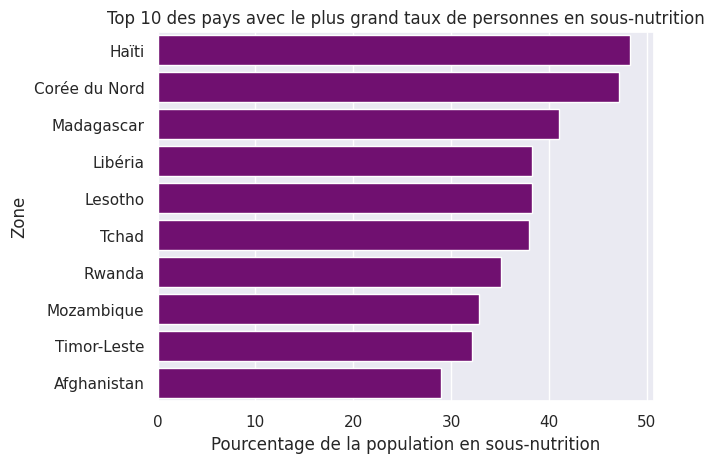

In [71]:
sns.barplot(df6_top10, x="Sous nutrition (%)", y="Zone", color="purple")
plt.xlabel("Pourcentage de la population en sous-nutrition")
plt.title("Top 10 des pays avec le plus grand taux de personnes en sous-nutrition")
plt.show()

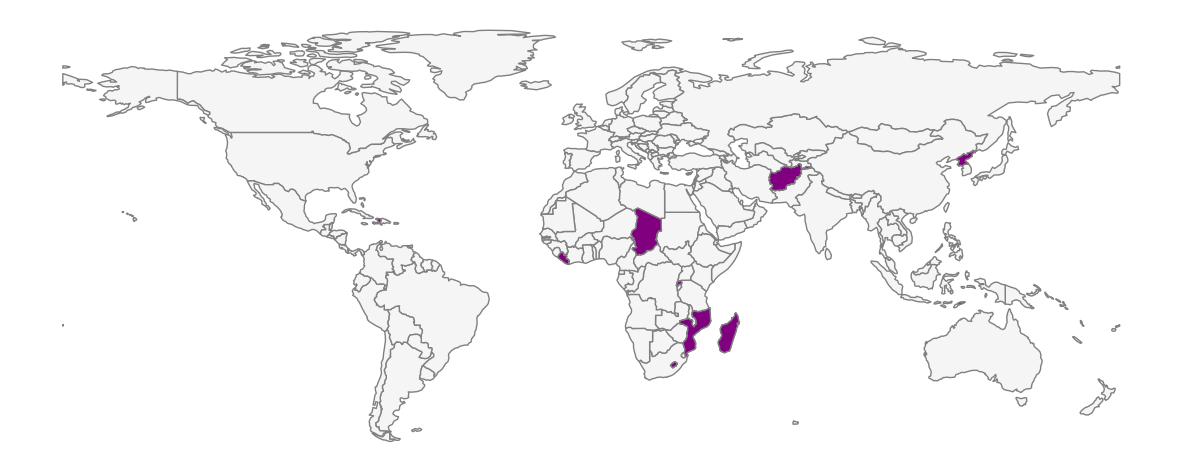

In [72]:
draw_world_map({
    "purple": {
        "Haiti",
        "Dem. Rep. Korea",
        "Madagascar",
        "Liberia",
        "Lesotho",
        "Chad",
        "Rwanda",
        "Mozambique",
        "Timor-Leste",
        "Afghanistan",
    },
})

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.7 - Pays qui ont le plus bénéficié de l'aide alimentaire entre 2013 et 2016</h3>
</div>

In [73]:
df7 = aide_alimentaire[["Zone","Aide alimentaire"]].groupby("Zone").sum()
df7 = df7.sort_values(by="Aide alimentaire", ascending=False).reset_index()
df7["Aide alimentaire (millions de tonnes)"] = df7["Aide alimentaire"] / 1e9
del df7["Aide alimentaire"]
df7

,Zone,Aide alimentaire (millions de tonnes)
0,République arabe syrienne,1.858943
1,Éthiopie,1.381294
2,Yémen,1.206484
3,Soudan du Sud,0.695248
4,Soudan,0.669784
...,...,...
71,Égypte,0.001122
72,Vanuatu,0.000802
73,Timor-Leste,0.000116
74,Géorgie,0.000070


In [74]:
df7_top10 = df7.head(10)
df7_top10

,Zone,Aide alimentaire (millions de tonnes)
0,République arabe syrienne,1.858943
1,Éthiopie,1.381294
2,Yémen,1.206484
3,Soudan du Sud,0.695248
4,Soudan,0.669784
5,Kenya,0.552836
6,Bangladesh,0.348188
7,Somalie,0.292678
8,République démocratique du Congo,0.288502
9,Niger,0.276344


In [75]:
df7_top10_plot = df7_top10.copy()
df7_top10_plot.loc[ (df7_top10_plot["Zone"] == "République arabe syrienne"), "Zone" ] = "Syrie"
df7_top10_plot.loc[ (df7_top10_plot["Zone"] == "République démocratique du Congo"), "Zone" ] = "RD Congo"
df7_top10_plot

,Zone,Aide alimentaire (millions de tonnes)
0,Syrie,1.858943
1,Éthiopie,1.381294
2,Yémen,1.206484
3,Soudan du Sud,0.695248
4,Soudan,0.669784
5,Kenya,0.552836
6,Bangladesh,0.348188
7,Somalie,0.292678
8,RD Congo,0.288502
9,Niger,0.276344


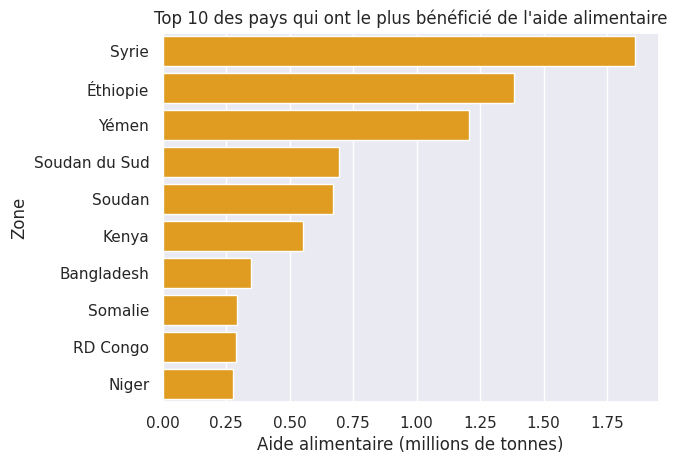

In [76]:
sns.barplot(df7_top10_plot, x="Aide alimentaire (millions de tonnes)", y="Zone", color="orange")
plt.title("Top 10 des pays qui ont le plus bénéficié de l'aide alimentaire")
plt.show()

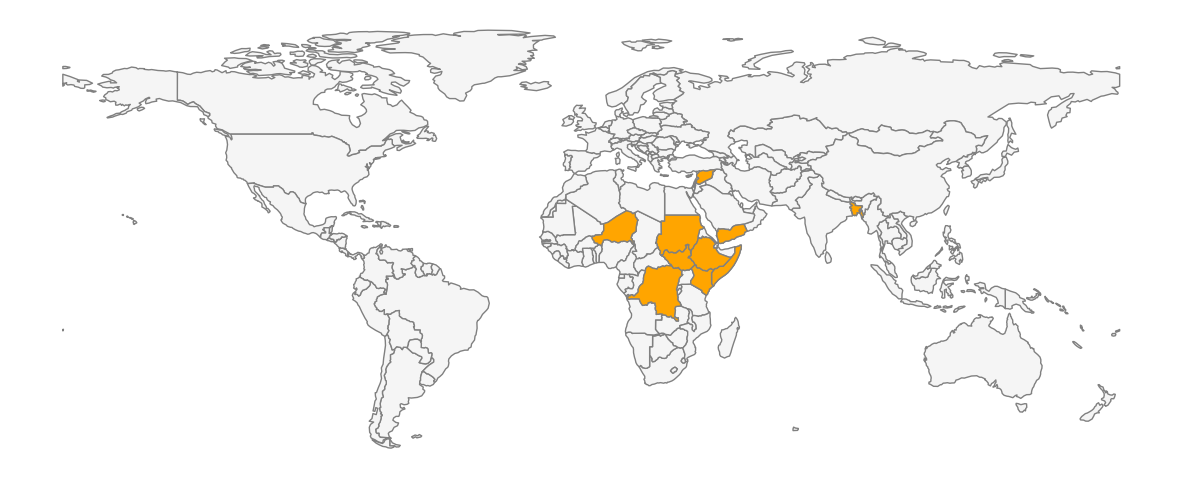

In [77]:
draw_world_map({
    "orange": {
        "Syria",
        "Ethiopia",
        "Yemen",
        "South Sudan",
        "Sudan",
        "Kenya",
        "Bangladesh",
        "Somalia",
        "Democratic Republic of the Congo",
        "Niger",
    },
})

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.8 - Evolution des 5 pays qui ont le plus bénéficié de l'aide alimentaire entre 2013 et 2016</h3>
</div>

In [78]:
pays_top5 = df7.iloc[:5]["Zone"]
pays_top5

0    République arabe syrienne
1                     Éthiopie
2                        Yémen
3                Soudan du Sud
4                       Soudan
Name: Zone, dtype: str

In [79]:
df8 = pd.merge(df7.iloc[:5][["Zone"]], aide_alimentaire)
df8 = df8[["Zone","Année","Aide alimentaire"]].groupby(["Zone","Année"]).sum().reset_index()
df8["Aide alimentaire (milliers de tonnes)"] = df8["Aide alimentaire"] / 1e6
del df8["Aide alimentaire"]
df8

,Zone,Année,Aide alimentaire (milliers de tonnes)
0,République arabe syrienne,2013,563.566
1,République arabe syrienne,2014,651.870
2,République arabe syrienne,2015,524.949
3,République arabe syrienne,2016,118.558
4,Soudan,2013,330.230
5,Soudan,2014,321.904
6,Soudan,2015,17.650
7,Soudan du Sud,2013,196.330
8,Soudan du Sud,2014,450.610
9,Soudan du Sud,2015,48.308


In [80]:
df8_plot = df8.copy()
df8_plot.loc[ (df8_plot["Zone"] == "République arabe syrienne"), "Zone" ] = "Syrie"
df8_plot

,Zone,Année,Aide alimentaire (milliers de tonnes)
0,Syrie,2013,563.566
1,Syrie,2014,651.870
2,Syrie,2015,524.949
3,Syrie,2016,118.558
4,Soudan,2013,330.230
5,Soudan,2014,321.904
6,Soudan,2015,17.650
7,Soudan du Sud,2013,196.330
8,Soudan du Sud,2014,450.610
9,Soudan du Sud,2015,48.308


In [81]:
pays_top5.loc[ (pays_top5 == "République arabe syrienne") ] = "Syrie"
pays_top5

0            Syrie
1         Éthiopie
2            Yémen
3    Soudan du Sud
4           Soudan
Name: Zone, dtype: str

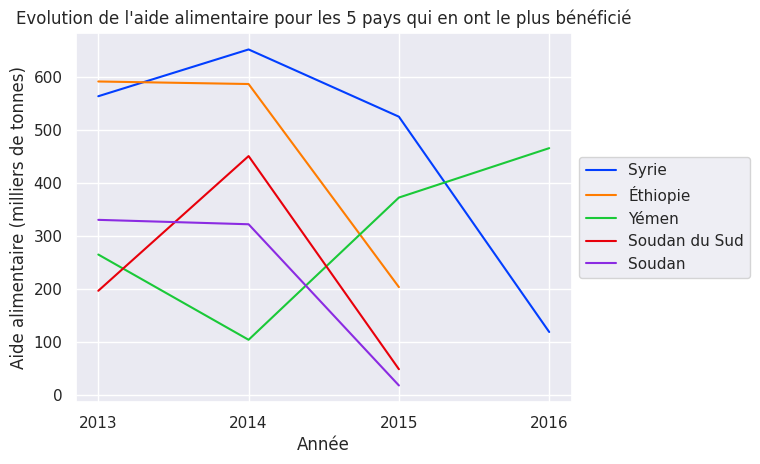

In [82]:
sns.lineplot(df8_plot, x="Année", y="Aide alimentaire (milliers de tonnes)", hue="Zone", hue_order=pays_top5)
plt.xticks(range(2013, 2017))
plt.legend(loc="center left", bbox_to_anchor=(1,0.5))
plt.title("Evolution de l'aide alimentaire pour les 5 pays qui en ont le plus bénéficié")
plt.show()

La guerre civile au Yémen est un facteur qui explique la hausse pour ce pays (voir [Wikipédia](https://fr.wikipedia.org/wiki/Guerre_civile_y%C3%A9m%C3%A9nite)).

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.9 - Pays avec le plus/moins de disponibilité par habitant</h3>
</div>

In [83]:
df9 = dispo_alimentaire[["Zone","Disponibilité alimentaire (Kcal/personne/jour)"]].groupby("Zone").sum()
df9 = df9.sort_values(by="Disponibilité alimentaire (Kcal/personne/jour)")
df9

,Disponibilité alimentaire (Kcal/personne/jour)
Zone,
République centrafricaine,1879.0
Zambie,1924.0
Madagascar,2056.0
Afghanistan,2087.0
Haïti,2089.0
...,...
Israël,3610.0
États-Unis d'Amérique,3682.0
Turquie,3708.0


In [84]:
df9.iloc[:10]

,Disponibilité alimentaire (Kcal/personne/jour)
Zone,
République centrafricaine,1879.0
Zambie,1924.0
Madagascar,2056.0
Afghanistan,2087.0
Haïti,2089.0
République populaire démocratique de Corée,2093.0
Tchad,2109.0
Zimbabwe,2113.0
Ouganda,2126.0


In [85]:
df9.iloc[:-11:-1]

,Disponibilité alimentaire (Kcal/personne/jour)
Zone,
Autriche,3770.0
Belgique,3737.0
Turquie,3708.0
États-Unis d'Amérique,3682.0
Israël,3610.0
Irlande,3602.0
Italie,3578.0
Luxembourg,3540.0
Égypte,3518.0


In [86]:
df9_plot = pd.concat([ df9[:-11:-1], df9[9::-1] ], keys=["max","min"], names=["Hue"]).reset_index()
df9_plot.loc[ (df9_plot["Zone"] == "États-Unis d'Amérique"), "Zone" ] = "États-Unis"
df9_plot.loc[ (df9_plot["Zone"] == "République populaire démocratique de Corée"), "Zone" ] = "Corée du Nord"
df9_plot.loc[ (df9_plot["Zone"] == "République centrafricaine"), "Zone" ] = "Centrafrique"
df9_plot

,Hue,Zone,Disponibilité alimentaire (Kcal/personne/jour)
0,max,Autriche,3770.0
1,max,Belgique,3737.0
2,max,Turquie,3708.0
3,max,États-Unis,3682.0
4,max,Israël,3610.0
5,max,Irlande,3602.0
6,max,Italie,3578.0
7,max,Luxembourg,3540.0
8,max,Égypte,3518.0
9,max,Allemagne,3503.0


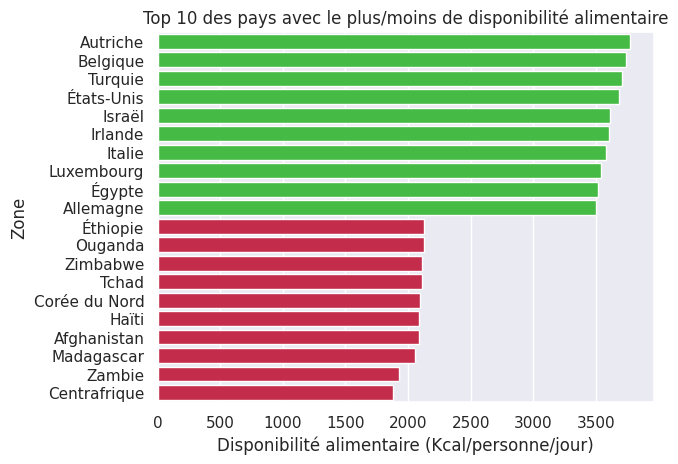

In [87]:
sns.barplot(df9_plot, x="Disponibilité alimentaire (Kcal/personne/jour)", y="Zone", hue="Hue", palette=["limegreen","crimson"], legend=False)
plt.title("Top 10 des pays avec le plus/moins de disponibilité alimentaire")
plt.show()

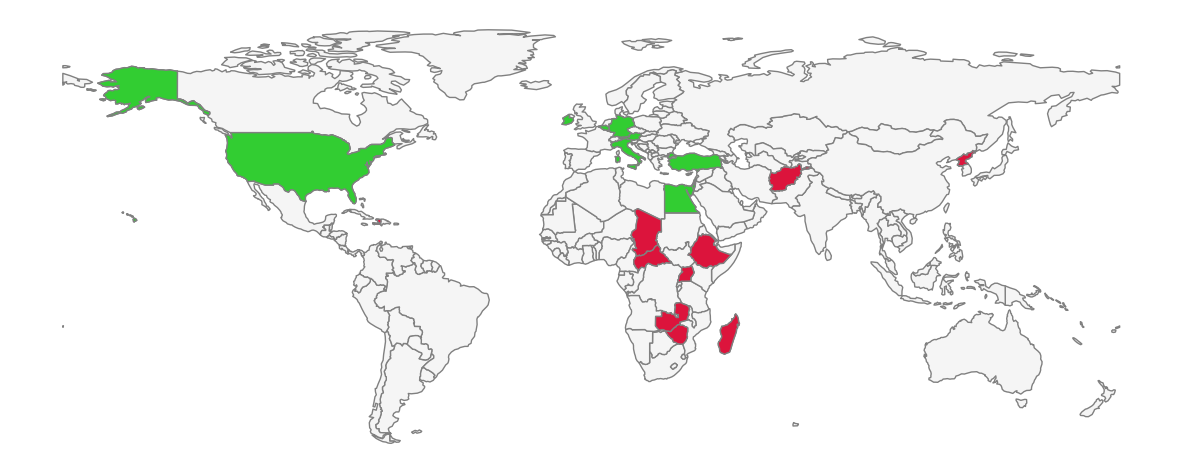

In [88]:
draw_world_map({
    "limegreen": {
        "Austria",
        "Belgium",
        "Turkey",
        "United States",
        "Israel",
        "Ireland",
        "Italy",
        "Luxembourg",
        "Egypt",
        "Germany",
    },
    "crimson": {
        "Central African Republic",
        "Zambia",
        "Madagascar",
        "Afghanistan",
        "Haiti",
        "Dem. Rep. Korea",
        "Chad",
        "Zimbabwe",
        "Uganda",
        "Ethiopia",
    },
})

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.10 - Exemple de la Thaïlande pour le manioc</h3>
</div>

In [89]:
den =     population_2017[ (    population_2017["Zone"] == "Thaïlande") ][    "Population"].sum()
num = sous_nutrition_2017[ (sous_nutrition_2017["Zone"] == "Thaïlande") ]["Sous nutrition"].sum()
print(f"En 2017 en Thaïlande, {num:_} personnes sur {den:_} sont en sous nutrition, soit {100.*num/den:.2f}% de la population.")

En 2017 en Thaïlande, 6_200_000 personnes sur 69_209_810 sont en sous nutrition, soit 8.96% de la population.


In [90]:
df10 = dispo_alimentaire[ (dispo_alimentaire["Zone"] == "Thaïlande") & (dispo_alimentaire["Produit"] == "Manioc") ].iloc[0]
df10

Zone                                                               Thaïlande
Produit                                                               Manioc
Origine                                                             vegetale
Aliments pour animaux                                             1800000000
Autres Utilisations                                               2081000000
Disponibilité alimentaire (Kcal/personne/jour)                          40.0
Disponibilité alimentaire en quantité (g/personne/jour)            35.616438
Disponibilité de matière grasse en quantité (g/personne/jour)           0.05
Disponibilité de protéines en quantité (g/personne/jour)                0.14
Disponibilité intérieure                                          6264000000
Exportations - Quantité                                          25214000000
Importations - Quantité                                           1250000000
Nourriture                                                         871000000

In [91]:
num = df10["Exportations - Quantité"]
den = df10["Production"]
print(f"Exportations = {num:_}, Production = {den:_}")
print(f"En 2017 en Thaïlande, {100.*num/den:.2f}% du manioc produit est exporté.")

Exportations = 25_214_000_000, Production = 30_228_000_000
En 2017 en Thaïlande, 83.41% du manioc produit est exporté.


In [92]:
num =                 df10["Disponibilité alimentaire (Kcal/personne/jour)"]
den = df9.loc["Thaïlande"]["Disponibilité alimentaire (Kcal/personne/jour)"]
print(f"Disponibilité alimentaire en 2017 en Thaïlande: manioc = {num:_}, totale = {den:_}, ratio = {100.*num/den:.2f}")

Disponibilité alimentaire en 2017 en Thaïlande: manioc = 40.0, totale = 2_785.0, ratio = 1.44


In [93]:
manioc = dispo_alimentaire[ (dispo_alimentaire["Produit"] == "Manioc") ]
manioc

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (g/personne/jour),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
110,Afrique du Sud,Manioc,vegetale,0,57000000,0.0,0.000000,0.00,0.00,57000000,2000000,58000000,0,0,0,0,0,1000000
203,Albanie,Manioc,vegetale,0,0,0.0,0.000000,0.00,0.00,0,0,0,0,0,0,0,0,0
295,Algérie,Manioc,vegetale,0,0,0.0,0.000000,0.00,0.00,0,0,0,0,0,0,0,0,0
390,Allemagne,Manioc,vegetale,1000000,26000000,0.0,0.000000,0.00,0.00,27000000,14000000,41000000,0,0,0,0,0,0
475,Angola,Manioc,vegetale,8880000000,0,560.0,542.191781,0.60,4.72,16412000000,0,0,4249000000,3282000000,16412000000,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15108,Égypte,Manioc,vegetale,0,0,0.0,0.000000,0.00,0.00,-1000000,3000000,1000000,0,0,0,0,0,0
15201,Émirats arabes unis,Manioc,vegetale,0,7000000,3.0,4.027397,0.01,0.03,20000000,1000000,21000000,14000000,0,0,0,0,0
15294,Équateur,Manioc,vegetale,0,1000000,6.0,6.931507,0.02,0.05,44000000,8000000,6000000,40000000,2000000,46000000,0,0,0
15390,États-Unis d'Amérique,Manioc,vegetale,288000000,245000000,0.0,0.383562,0.00,0.00,579000000,9000000,588000000,46000000,0,0,0,0,0


In [94]:
manioc_export = manioc[["Zone","Exportations - Quantité"]].sort_values(by="Exportations - Quantité", ascending=False)
manioc_export.head(10)

,Zone,Exportations - Quantité
13809,Thaïlande,25214000000
14743,Viet Nam,8973000000
6334,Indonésie,820000000
2665,Cambodge,254000000
10752,Paraguay,164000000
3698,Costa Rica,123000000
3228,"Chine, Taiwan Province de",82000000
3043,Chine - RAS de Hong-Kong,80000000
10386,Ouganda,47000000
3323,"Chine, continentale",41000000


In [95]:
manioc_import = manioc[["Zone","Importations - Quantité"]].sort_values(by="Importations - Quantité", ascending=False)
manioc_import.head(10)

,Zone,Importations - Quantité
3323,"Chine, continentale",29046000000
11769,République de Corée,1933000000
3228,"Chine, Taiwan Province de",1324000000
13809,Thaïlande,1250000000
6334,Indonésie,1102000000
8378,Malaisie,844000000
7073,Japon,637000000
15390,États-Unis d'Amérique,588000000
10940,Philippines,276000000
1303,Bangladesh,147000000


La Thaïlande est le 1er pays exportateur de manioc et le 4ème pays importateur de manioc.

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyses complémentaires</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">
4.1 - Liste des 10 pays avec le plus de personnes en sous nutrition en 2017
</h3>
</div>

In [96]:
df11 = sous_nutrition_2017.sort_values(by="Sous nutrition", ascending=False).head(10)
df11['Sous nutrition'] /= 1e6
df11

,Zone,Sous nutrition
508,Inde,190.1
820,Pakistan,24.8
514,Indonésie,23.6
772,Nigéria,22.8
100,Bangladesh,21.5
370,Éthiopie,21.1
868,Philippines,15.7
952,République-Unie de Tanzanie,13.4
946,République populaire démocratique de Corée,12.0
580,Kenya,11.9


In [97]:
df11_plot = df11.copy()
df11_plot.loc[ (df11_plot["Zone"] == "République-Unie de Tanzanie"), "Zone" ] = "Tanzanie"
df11_plot.loc[ (df11_plot["Zone"] == "République populaire démocratique de Corée"), "Zone" ] = "Corée du Nord"
df11_plot

,Zone,Sous nutrition
508,Inde,190.1
820,Pakistan,24.8
514,Indonésie,23.6
772,Nigéria,22.8
100,Bangladesh,21.5
370,Éthiopie,21.1
868,Philippines,15.7
952,Tanzanie,13.4
946,Corée du Nord,12.0
580,Kenya,11.9


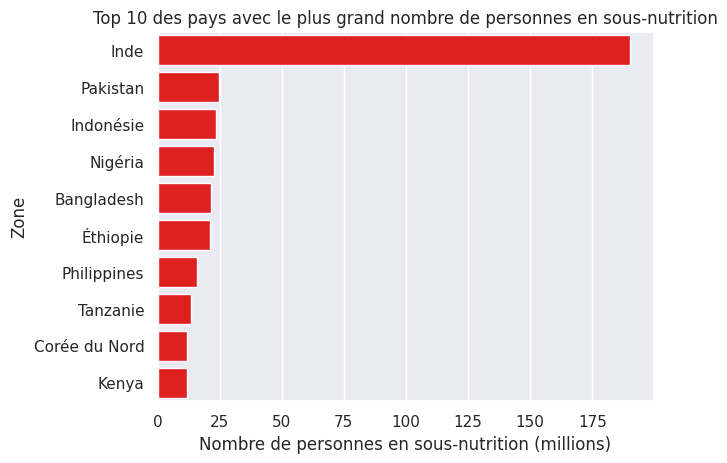

In [98]:
sns.barplot(df11_plot, x="Sous nutrition", y="Zone", color="red")
plt.xlabel("Nombre de personnes en sous-nutrition (millions)")
plt.title("Top 10 des pays avec le plus grand nombre de personnes en sous-nutrition")
plt.show()

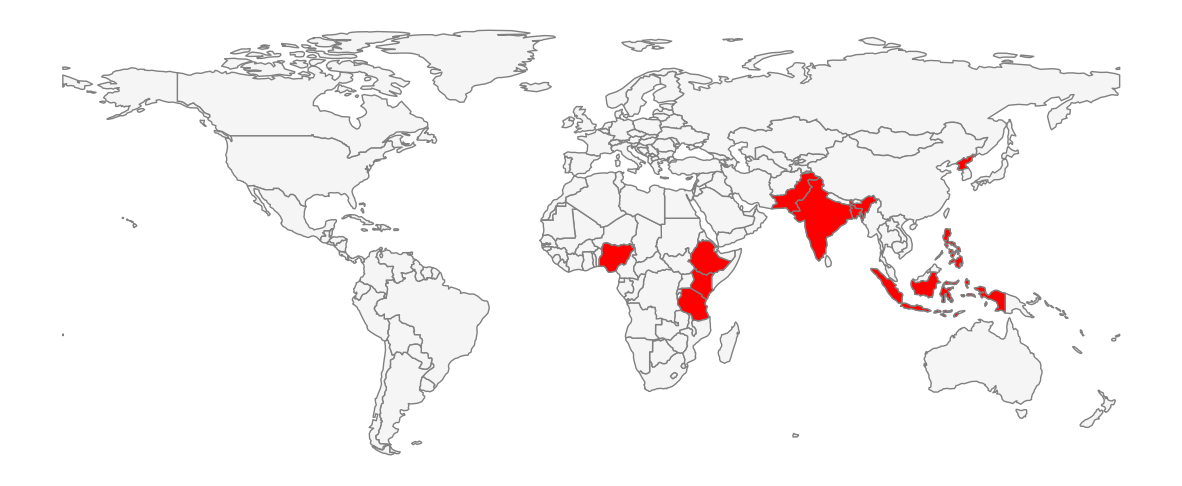

In [99]:
draw_world_map({
    "red": {
        "India",
        "Pakistan",
        "Indonesia",
        "Nigeria",
        "Bangladesh",
        "Ethiopia",
        "Philippines",
        "Tanzania",
        "Dem. Rep. Korea",
        "Kenya",
    }
})

In [100]:
df6[ df6["Zone"].isin([ "Inde", "Haïti" ]) ]

,Zone,Population,Sous nutrition,Sous nutrition (%)
78,Haïti,10982366,5300000,48.259182
84,Inde,1338676785,190100000,14.200590


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">
4.2 - Evolution de la population mondiale
</h3>
</div>

In [101]:
population_totale = population[["Année","Population"]].groupby("Année").sum().reset_index()
population_totale["Population mondiale (milliards)"] = population_totale["Population"] / 1e9
population_totale

,Année,Population,Population mondiale (milliards)
0,2013,7210845833,7.210846
1,2014,7295557761,7.295558
2,2015,7380067062,7.380067
3,2016,7464294728,7.464295
4,2017,7548134097,7.548134
5,2018,7631368510,7.631369


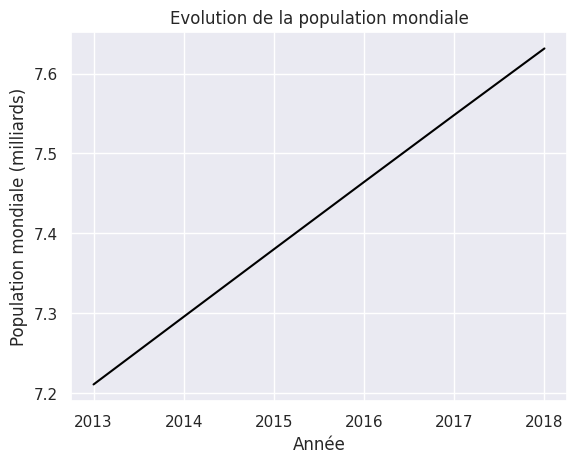

In [102]:
sns.lineplot(population_totale, x="Année", y="Population mondiale (milliards)", color="black")
plt.title("Evolution de la population mondiale")
plt.show()

In [103]:
for annee in range(2013, 2018):
    x = population_totale.loc[ (population_totale["Année"] == annee    ), "Population" ].iloc[0]
    y = population_totale.loc[ (population_totale["Année"] == annee + 1), "Population" ].iloc[0]
    print(f"Taux de croissance de {annee} à {annee+1} = {100.*(y-x)/x:.2f}%")

Taux de croissance de 2013 à 2014 = 1.17%
Taux de croissance de 2014 à 2015 = 1.16%
Taux de croissance de 2015 à 2016 = 1.14%
Taux de croissance de 2016 à 2017 = 1.12%
Taux de croissance de 2017 à 2018 = 1.10%


De 2013 à 2018, la population mondiale est en croissance quasi-constante.

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">
4.3 - Evolution de la sous nutrition à l'échelle mondiale
</h3>
</div>

In [104]:
sous_nutrition_totale = sous_nutrition[["Année","Sous nutrition"]].groupby("Année").sum().reset_index()
sous_nutrition_totale["Personnes en sous-nutrition (millions)"] = sous_nutrition_totale["Sous nutrition"] / 1e6
sous_nutrition_totale

,Année,Sous nutrition,Personnes en sous-nutrition (millions)
0,2013,528100000,528.100000
1,2014,523500000,523.500000
2,2015,524700000,524.700000
3,2016,528599999,528.599999
4,2017,535700000,535.700000
5,2018,544200000,544.200000


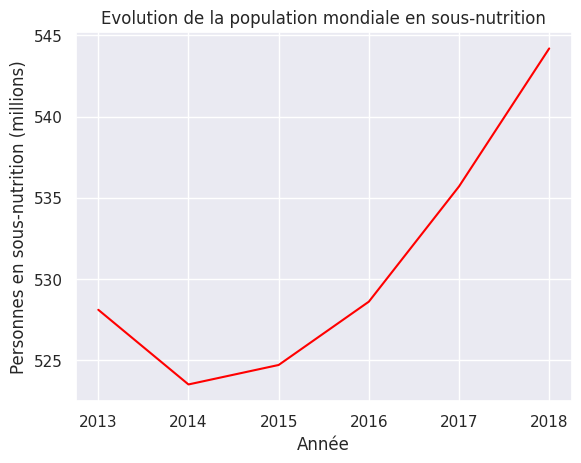

In [105]:
sns.lineplot(sous_nutrition_totale, x="Année", y="Personnes en sous-nutrition (millions)", color="red")
plt.title("Evolution de la population mondiale en sous-nutrition")
plt.show()

In [106]:
for annee in range(2013, 2018):
    x = sous_nutrition_totale.loc[ (sous_nutrition_totale["Année"] == annee    ), "Sous nutrition" ].iloc[0]
    y = sous_nutrition_totale.loc[ (sous_nutrition_totale["Année"] == annee + 1), "Sous nutrition" ].iloc[0]
    print(f"Taux de croissance de {annee} à {annee+1} = {100.*(y-x)/x:.2f}%")

Taux de croissance de 2013 à 2014 = -0.87%
Taux de croissance de 2014 à 2015 = 0.23%
Taux de croissance de 2015 à 2016 = 0.74%
Taux de croissance de 2016 à 2017 = 1.34%
Taux de croissance de 2017 à 2018 = 1.59%


Le nombre de personnes en sous-nutrition baisse en 2014 puis augmente de plus en plus.

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">
4.4 - Evolution de l'aide alimentaire à l'échelle mondiale
</h3>
</div>

In [107]:
aide_alimentaire_totale = aide_alimentaire[["Année","Aide alimentaire"]].groupby("Année").sum().reset_index()
aide_alimentaire_totale["Aide alimentaire (millions de tonnes)"] = aide_alimentaire_totale["Aide alimentaire"] / 1e9
aide_alimentaire_totale

,Année,Aide alimentaire,Aide alimentaire (millions de tonnes)
0,2013,4165674000,4.165674
1,2014,3939152000,3.939152
2,2015,2187507000,2.187507
3,2016,743568000,0.743568


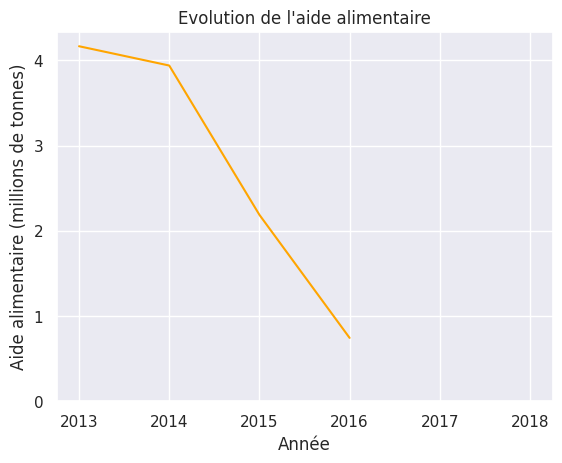

In [108]:
sns.lineplot(aide_alimentaire_totale, x="Année", y="Aide alimentaire (millions de tonnes)", color="orange")
plt.xticks(range(2013,2019))
plt.xlim(2013-0.25, 2018+0.25)
plt.yticks(range(0,5))
plt.title("Evolution de l'aide alimentaire")
plt.show()

In [109]:
for annee in range(2013, 2016):
    x = aide_alimentaire_totale.loc[ (aide_alimentaire_totale["Année"] == annee    ), "Aide alimentaire" ].iloc[0]
    y = aide_alimentaire_totale.loc[ (aide_alimentaire_totale["Année"] == annee + 1), "Aide alimentaire" ].iloc[0]
    print(f"Taux de croissance de {annee} à {annee+1} = {100.*(y-x)/x:.2f}%")

Taux de croissance de 2013 à 2014 = -5.44%
Taux de croissance de 2014 à 2015 = -44.47%
Taux de croissance de 2015 à 2016 = -66.01%


L'aide alimentaire diminue très fortement depuis 2014.